<a href="https://colab.research.google.com/github/DhruvGangwar320/GitHUB/blob/main/ML_linearRegression%2BrankCorrelation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Linear Regression



In [ ]:
# Linear Regression

In [13]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# sample data
# Raw data from the problem statement
raw_data = [
    "1951: 359.0 million",
    "1961: 439.2 million",
    "1971: 548.2 million",
    "1981: 683.3 million",
    "1991: 846.4 million",
    "2001: 1,028.7 million",
    "2011: 1,210.9 million",
    "2015: 1,328.0 million",
    "2018: 1,374.7 million",
    "2020: 1,402.6 million",
    "2021: 1,414.2 million",
    "2022: 1,425.4 million",
    "2023: 1,438.1 million",
    "2024: 1,450.9 million",
    "2025: 1,463.9 million"
]

years = []
populations = []

for entry in raw_data:
    parts = entry.split(': ')
    year = int(parts[0])
    population_str = parts[1].replace(' million', '').replace(',', '')
    population = float(population_str) * 1_000_000 # Convert to actual number
    years.append(year)
    populations.append(population)

x = np.array(years)
y = np.array(populations)

print("Years:", x)
print("Populations:", y)

Years: [1951 1961 1971 1981 1991 2001 2011 2015 2018 2020 2021 2022 2023 2024
 2025]
Populations: [3.5900e+08 4.3920e+08 5.4820e+08 6.8330e+08 8.4640e+08 1.0287e+09
 1.2109e+09 1.3280e+09 1.3747e+09 1.4026e+09 1.4142e+09 1.4254e+09
 1.4381e+09 1.4509e+09 1.4639e+09]


In [ ]:
x_mean = np.mean(x);
y_mean = np.mean(y);

In [ ]:
nom = np.array([])
for i in range(len(x)):
  nom = np.append(nom, (x[i] - x_mean) * (y[i] - y_mean))
cov  = np.sum(nom)/(len(x)-1)
cov

np.float64(10221538095.238094)

In [ ]:
x_std = np.std(x)
y_std = np.std(y)
slope = cov / x_std**2
slope

np.float64(17325945.995393787)

In [ ]:
intercept  = y_mean - slope*x_mean
intercept

np.float64(-33598085864.77683)

In [ ]:
y_pred = slope*x + intercept

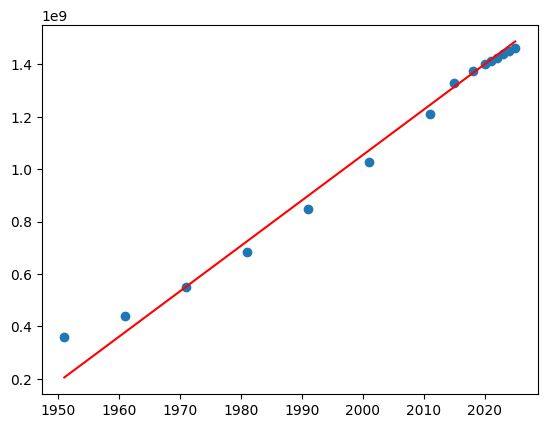

In [ ]:
plt.scatter(x,y)
plt.plot(x,y_pred,color='red')
plt.show()

#Rank Correlation

In [1]:
# For single data series
# formula , phai = 1 - [6*(Σd**2+T)]/n(n**2 - 1)
# Here T is the correction of ranks between tied ranks
# T = Σm(m**2 - 1)/12
from collections import Counter

class RankCorrelation:
    def __init__(self, list1, list2):
        if len(list1) != len(list2):
            raise ValueError("Lists must be of equal length")
        self.raw_x = list1
        self.raw_y = list2
        self.n = len(list1)

    def _get_ranks(self, data):
        """
        Assigns ranks to data, handling ties by averaging.
        Returns a list of ranks corresponding to the original order.
        """
        # 1. Pair values with their original indices
        val_with_idx = [(val, i) for i, val in enumerate(data)]

        # 2. Sort by value (Descending order for ranking)
        val_with_idx.sort(key=lambda x: x[0], reverse=True)

        ranks = [0.0] * self.n
        i = 0
        while i < self.n:
            j = i
            # Find all identical values (ties)
            while j < self.n - 1 and val_with_idx[j][0] == val_with_idx[j + 1][0]:
                j += 1

            # Calculate average rank
            # Ranks are 1-based, so we use (i + 1) to (j + 1)
            # Sum of indices divided by count
            n_ties = j - i + 1
            sum_ranks = sum(range(i + 1, j + 2))
            avg_rank = sum_ranks / n_ties

            # Assign this rank to all tied indices
            for k in range(i, j + 1):
                original_idx = val_with_idx[k][1]
                ranks[original_idx] = avg_rank

            i = j + 1

        return ranks

    def calculate(self):
        # 1. Get Ranks (Preserving order!)
        rx = self._get_ranks(self.raw_x)
        ry = self._get_ranks(self.raw_y)

        # 2. Calculate d^2 (Difference between ranks)
        d_squared_sum = sum((rx[i] - ry[i])**2 for i in range(self.n))

        # 3. Calculate Correction Factor (T)
        # T is calculated for both lists based on tie counts (m)
        def get_correction(data):
            counts = Counter(data)
            correction = 0
            for val in counts:
                m = counts[val]
                if m > 1:
                    correction += (m * (m**2 - 1)) / 12
            return correction

        T = get_correction(self.raw_x) + get_correction(self.raw_y)
        # 4. Apply Formula
        # Formula: 1 - (6 * (Sum_d2 + T)) / (n * (n^2 - 1))
        numerator = 6 * (d_squared_sum + T)
        denominator = self.n * (self.n**2 - 1)

        rho = 1 - (numerator / denominator)
        return rho

# --- Test Case ---
# Using the Math vs Physics marks example we discussed earlier
math_marks = [10, 8, 8, 5, 2]
phys_marks = [10, 6, 6, 6, 4]

rc = RankCorrelation(math_marks, phys_marks)
result = rc.calculate()

print(f"Spearman's Correlation: {result}")
# Expected output based on our manual calculation: 0.8
properties_of_correlation = [
    "(i) Range: The correlation coefficient lies between -1 and +1. (-1 <= r(x, y) <= 1)",

    "(ii) Perfect Positive: If r = 1, then the coefficient of correlation is perfectly positive.",

    "(iii) Perfect Negative: If r = -1, the correlation is perfectly negative.",

    "(iv) Unitless: The correlation coefficient is a pure number independent of the unit of measurement.",

    "(v) Origin and Scale: The coefficient of correlation is independent of the change in origin and scale.",

    "(vi) Degree and Direction: If -1 < r < 1, it indicates the degree of linear relationship between x and y, whereas its sign tells about the direction of relationship.",

    "(vii) Independence: If x and y are two independent variables, then r = 0.",

    "(viii) Uncorrelated vs. Independent: If r = 0, x and y are said to be uncorrelated. However, it does not imply that the two variates are independent.",

    "(ix) Linear Transformation: If x and y are random variables and a, b, c, d are constants (a!=0, c!=0), then r(ax + b, cy + d) = (|ac|/ac) * r(x, y)."
]

for prop in properties_of_correlation:
    print(prop)

(i) Range: The correlation coefficient lies between -1 and +1. (-1 <= r(x, y) <= 1)
(ii) Perfect Positive: If r = 1, then the coefficient of correlation is perfectly positive.
(iii) Perfect Negative: If r = -1, the correlation is perfectly negative.
(iv) Unitless: The correlation coefficient is a pure number independent of the unit of measurement.
(v) Origin and Scale: The coefficient of correlation is independent of the change in origin and scale.
(vi) Degree and Direction: If -1 < r < 1, it indicates the degree of linear relationship between x and y, whereas its sign tells about the direction of relationship.
(vii) Independence: If x and y are two independent variables, then r = 0.
(viii) Uncorrelated vs. Independent: If r = 0, x and y are said to be uncorrelated. However, it does not imply that the two variates are independent.
(ix) Linear Transformation: If x and y are random variables and a, b, c, d are constants (a!=0, c!=0), then r(ax + b, cy + d) = (|ac|/ac) * r(x, y).


# LINES OF REGRESSION


In [19]:
import numpy as np

class lines_of_regression:
    def __init__(self, list1, list2):
        self.x = np.array(list1)
        self.y = np.array(list2)
        self.n = len(self.x)

    def calculate_regression_coefficient(self):
        # Calculate standard deviations
        stdx = np.std(self.x)
        stdy = np.std(self.y)

        # Calculate sums
        x_sum = np.sum(self.x)
        y_sum = np.sum(self.y)
        x2_sum = np.sum(self.x**2)
        y2_sum = np.sum(self.y**2)
        xy_sum = np.sum(self.x * self.y)

        # User's formula (with syntax correction: added '*' between terms)
        # Note: This formula is statistically flawed but runs as requested.
        try:
            numerator = (xy_sum - (x_sum * y_sum))
            denominator = int(((x2_sum - (x_sum)**2) * (y2_sum - (y_sum)**2))**(1/2))
            r = numerator / denominator
        except ZeroDivisionError:
            r = 0

        return r, stdx, stdy

# Data
years = [1951, 1961, 1971, 1981]
populations = [321, 56, 455, 54]

# Create object
obj = lines_of_regression(populations, years)

# Calculate and print
print(obj.calculate_regression_coefficient())

(np.float64(-1.120995482041065), np.float64(173.11051383437115), np.float64(11.180339887498949))


In [20]:
import numpy as np

# Calculate sin of 90 degrees
angle_degrees = 90
angle_radians = np.deg2rad(angle_degrees)

print(np.sin(angle_radians))  # Output: 1.0

1.0
